# HEOM auf einem durchgängigen Gitter — **ohne Kompression**

Ein Zustand geht bei $t=0$ hinein, dasselbe Gatter wird $n$-mal angewandt, bei $t=T$
kommt die Dichtematrix heraus. Dazwischen wird **nichts** ausgelesen, **nichts** neu
präpariert und **nichts** klassisch propagiert.

Der Unterschied zur komprimierten Variante in `../../main_durchgaengiges_grid.ipynb` ist
genau ein weggelassener Schritt — und es ist der einzige, der überhaupt etwas
Trajektorienartiges klassisch gerechnet hat:

| | komprimiert | **hier** |
|---|---|---|
| Erzeuger $A$ aufstellen | ✓ | ✓ |
| Eichung | Lyapunov, dicht $O(n^3)$ | **ADO-Skalierung, diagonal $O(n)$** |
| $P=\exp(A\Delta t)$ | ✓ | ✓ |
| **Arnoldi: $m$ Anwendungen von $P$** | **✓** | **entfällt** |
| Dilatation | auf $H_m$ ($m=128$) | auf $P$ ($n=720$) |
| Qubits | 8 | 11 |

Arnoldi ist keine Zeitpropagation im physikalischen Sinn, aber es sind $m$ Anwendungen
von $P$ auf einen Vektor — $m$-mal „die Dynamik anfassen". Ohne Kompression fällt das
weg. Der Schaltkreis arbeitet direkt im vollen HEOM-Raum.

### Was klassisch übrig bleibt

| Schritt | Kosten | hängt ab von der Zahl der Zeitschritte? | skaliert? |
|---|---|---|---|
| $A$ aufstellen | $O(n)$ Nichtnullen, dünn | nein | **ja** |
| ADO-Skalierung (diagonal) | $O(n)$, eintragsweise | nein | **ja** |
| $P=\exp(A\Delta t)$ | **dicht $O(n^3)$** | nein | **nein** |
| Dilatation (zwei Matrixwurzeln) | **dicht $O(n^3)$** | nein | **nein** |
| $U$ als Gatter laden | $2^{2q}$ Amplituden | nein | **nein** |
| Anfangszustand | $\lvert0\dots0\rangle$ | nein | **ja** |
| Ablesung | diagonal, $d^2$ Einträge | nein | **ja** |

Kein einziger Schritt hängt von der Zahl der Zeitschritte ab — das ist die Aussage, um
die es geht, und sie gilt hier unverändert. Drei Schritte hängen aber sehr wohl von der
Hilbertraum-**Dimension** ab, und das ist eine andere Aussage. Was das für ein
$10^{30}\times10^{30}$-System bedeutet, steht in [`kritik.ipynb`](kritik.ipynb) — die
kurze Antwort ist: so nicht.

In [1]:
import os, sys, time
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt

from heom_full import (build_grid_full, build_circuit_full, estimate_cost,
                       run_full, run_full_counts, counts_cost,
                       qutip_reference, qutip_reference_rho)

PIC = 'pictures'
os.makedirs(PIC, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.titlesize': 10, 'legend.fontsize': 8})
print('bereit')

bereit


## 1  Das Modell

Vier-Site-FMO, Drude-Lorentz-Bad, **Hierarchietiefe 2** und $N_k=1$
Matsubara-Term. Das gibt 45 ADOs und damit $n = 45\cdot d^2 = 720$ Koordinaten —
gepolstert auf $1024 = 2^{10}$, plus eine Ancilla für die Dilatation: **11 Qubits**.

In [3]:
_C_CM    = 2.99792458e10                 # Lichtgeschwindigkeit [cm/s]
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM     # tau[cm] pro t[fs]
KB_CM    = 0.6950348004                  # Boltzmann [cm^-1/K]

N = 4
H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                  [-87.7, 12495.0,  30.8,   8.2],
                  [5.5,      30.8, 12175.0, -53.4],
                  [-5.9,      8.2, -53.4, 12285.0]])
H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)

MODEL = dict(H=H_FMO, lam=35.0, gamma=50.0, T_K=300.0,
             KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)

rho0    = np.diag([1.0] + [0.0] * (N - 1))   # Anregung auf Site 1
dt_fs   = 10.0
DEPTH   = 2          # ohne Kompression: Tiefe 2 haelt n bei 720
NK      = 1

# Der Testlauf hier ist bewusst klein.  Was ein voller Lauf kostet, rechnet
# Abschnitt 3 aus, bevor er gestartet wird.
N_STEPS = 100         # 100 fs
SHOTS   = 64
EVERY   = 2

cols = plt.cm.tab10(np.arange(N))
print(f"{N}-Site-FMO, dt = {dt_fs} fs, Tiefe {DEPTH}, Nk = {NK}")

4-Site-FMO, dt = 10.0 fs, Tiefe 2, Nk = 1


## 2  Warum die ADO-Skalierung und nicht die Lyapunov-Eichung

Die Sz.-Nagy-Dilatation

$$U=\begin{pmatrix} P/s & B\\ C & -(P/s)^\dagger\end{pmatrix},\qquad s\ge\lVert P\rVert_2$$

ist nur unitär, wenn $s\ge\lVert P\rVert_2$, und die Post-Selektion zahlt dafür
$p_t = s^{-2t}$ mal dem physikalischen Verlust. Der ungeeichte HEOM-Propagator hat
$\lVert P\rVert_2\approx 10{,}7$ — nach 100 Schritten bliebe davon $10{,}7^{-200}$ übrig.
Zwei Reparaturen stehen zur Wahl, und sie unterscheiden sich fundamental:

* **Lyapunov-Eichung** $(\mathcal{L}-\delta)^\dagger W + W(\mathcal{L}-\delta) = -\mathbb{1}$,
  dann $\tilde P = W^{1/2}PW^{-1/2}$. Wirkt exzellent, ist aber ein **dichter
  $O(n^3)$-Schritt** und produziert eine dichte Matrix $W^{\pm1/2}$.
* **ADO-Skalierung** (Shi et al.) $\rho_{\mathbf n}\to\rho_{\mathbf n}/\sqrt{\prod_k n_k!\,\lvert c_k\rvert^{n_k}}$.
  Das ist eine **diagonale** Ähnlichkeitstransformation — exakt, eintragsweise
  berechenbar, $O(n)$.

Die nächste Zelle misst beide. Wenn die diagonale Variante allein reicht, ist sie die
richtige Wahl, denn sie ist die einzige der beiden, die für ein großes System überhaupt
eine Perspektive hat.

In [6]:
from heom_gauge import heom_generator, contraction_gauge, lyapunov_schur, safe_norm2
from scipy.linalg import expm

dt_cm = dt_fs * FS_TO_CM
zeile = []
for gauge, sc in (('keine', False), ('ADO (diagonal)', True)):
    A, _ = heom_generator(depth=DEPTH, Nk=NK, scale_ados=sc, **MODEL)
    P = expm(A * dt_cm)
    zeile.append((gauge, safe_norm2(P), 'O(n), diagonal' if sc else '--'))
    if sc:                                    # zusaetzlich die dichte Variante
        t0 = time.time()
        Wh, Wih, gi = contraction_gauge(A, delta=0.02, schur_factor=lyapunov_schur(A))
        zeile.append((f'ADO + Lyapunov', safe_norm2(Wh @ P @ Wih),
                      f'O(n^3), {time.time()-t0:.0f} s, cond(W)={gi["cond"]:.1e}'))

print(f"  {'Eichung':16s} {'||P||_2':>12s} {'p(100) allein aus der Dilatation':>34s}   Kosten")
print("  " + "-" * 96)
for name, nP, kosten in zeile:
    p100 = nP ** -200 if nP > 1 else 1.0
    print(f"  {name:16s} {nP:12.8f} {p100:34.3e}   {kosten}")
print("""
  -> Die diagonale ADO-Skalierung allein bringt ||P|| dicht genug an 1.  Die
     Lyapunov-Eichung gewinnt danach nur noch wenig, kostet aber einen dichten
     O(n^3)-Schritt.  Ab hier wird deshalb NUR die diagonale Variante verwendet.""")

  Eichung               ||P||_2   p(100) allein aus der Dilatation   Kosten
  ------------------------------------------------------------------------------------------------
  keine            1166.46345221                          0.000e+00   --
  ADO (diagonal)     1.00792954                          2.060e-01   O(n), diagonal
  ADO + Lyapunov     1.00001730                          9.965e-01   O(n^3), 6 s, cond(W)=3.0e+05

  -> Die diagonale ADO-Skalierung allein bringt ||P|| dicht genug an 1.  Die
     Lyapunov-Eichung gewinnt danach nur noch wenig, kostet aber einen dichten
     O(n^3)-Schritt.  Ab hier wird deshalb NUR die diagonale Variante verwendet.


## 3  Das eine Gatter bauen

Einmalig, und **unabhängig von der Zahl der Zeitschritte**. Die vier Teilschritte werden
einzeln getaktet, damit man sieht, wo die Zeit hingeht — das ist genau die Information,
die [`kritik.ipynb`](kritik.ipynb) für die Skalierungsfrage braucht.

In [9]:
grid = build_grid_full(dt_fs, depth=DEPTH, Nk=NK, scale_ados=True, **MODEL)

print()
print(f"  Ablesung                             : diagonal, {grid['D']} Eintraege")
print(f"  Gatter U im Speicher                 : "
      f"{(2*grid['np_'])**2 * 16 / 2**20:.0f} MB")

  [1/4] Erzeuger A: 720 x 720 (45 ADOs, Tiefe 2, Nk=1)   0.0 s
  [2/4] P = expm(A dt): ||P||_2 = 1.00792954   1.4 s
  [3/4] Dilatation: 720 -> 1024 gepolstert, U ist 2048 x 2048 = 11 Qubits, s = 1.00792954   10.7 s
  [4/4] Anfangszustand |0,...,0> -- keine State-Preparation, ||x~0|| = 1
  Konstruktion gesamt: 12.2 s   (einmalig, unabhaengig von der Zahl der Zeitschritte)
  Post-Selektion allein aus der Dilatation: s^-200 = 0.2060 nach 100 Schritten

  Ablesung                             : diagonal, 16 Eintraege
  Gatter U im Speicher                 : 64 MB


## 4  Bevor der Lauf startet: was kostet er?

Aer simuliert jeden Shot als eigene Trajektorie, weil die Ancilla-Messung mitten im
Schaltkreis den Zustand kollabieren lässt. Die Kosten sind deshalb linear in
(Schritte × Shots), und ein kurzer Testlauf genügt zur Hochrechnung.

Die Zelle misst das an einem Mini-Schaltkreis und rechnet dann sowohl den geplanten
Lauf als auch mehrere größere Varianten hoch — damit man **vorher** weiß, ob ein
Lauf durchführbar ist.

In [10]:
est = estimate_cost(grid, N_STEPS, SHOTS)

print(f"\n  Was groessere Laeufe kosten wuerden (dieselbe Maschine):")
print(f"  {'Schritte':>9s} {'T [fs]':>8s} {'Shots':>7s} {'Anwendungen':>13s} {'geschaetzt':>12s}")
for ns, sh in ((10, 64), (50, 64), (100, 64), (100, 256), (100, 512), (500, 512)):
    sek = est['per_application'] * ns * sh
    print(f"  {ns:9d} {ns*dt_fs:8.0f} {sh:7d} {ns*sh:13,d} "
          f"{sek/60:10.1f} min")
print("""
  Hinweis zu den Shots: die spurnormierte Ablesung braucht GAR KEINE Statistik --
  der akzeptierte Zweig ist deterministisch, ein einziger angenommener Shot traegt
  den exakten Zustand.  Shots braucht nur p_t, und das geht in die absolute Skala
  ein.  Wer nur die Populationen will, kommt mit sehr wenigen Shots aus.""")

  Kostenschaetzung (aus 3 Schritten x 8 Shots, 2.27 s gemessen)
    Qubits                  : 11 (1024 Zustaende + 1 Ancilla)
    Gatter U im Speicher    : 64 MB
    Gatteranwendungen       : 100 x 64 = 6,400
    pro Anwendung           : 94.8 ms
    HOCHRECHNUNG            : 10.1 min (606 s)

  Was groessere Laeufe kosten wuerden (dieselbe Maschine):
   Schritte   T [fs]   Shots   Anwendungen   geschaetzt
         10      100      64           640        1.0 min
         50      500      64         3,200        5.1 min
        100     1000      64         6,400       10.1 min
        100     1000     256        25,600       40.4 min
        100     1000     512        51,200       80.9 min
        500     5000     512       256,000      404.3 min

  Hinweis zu den Shots: die spurnormierte Ablesung braucht GAR KEINE Statistik --
  der akzeptierte Zweig ist deterministisch, ein einziger angenommener Shot traegt
  den exakten Zustand.  Shots braucht nur p_t, und das geht in die absolute 

## 5  Der Lauf

Ein durchgängiger Schaltkreis: Register in $\lvert0\dots0\rangle$, dann $n$-mal dasselbe
$U$, dazwischen nur die Ancilla-Messung mit sofortigem Reset. Die Ancilla ist der Preis
der Dilatation, keine Unterbrechung der Propagation — der HEOM-Zustand selbst wird
zwischen $t=0$ und $t=T$ nie angefasst.

Die Shots laufen in **Stapeln**, damit man den Fortschritt sieht. Das unterbricht den
Schaltkreis nicht: jeder einzelne Shot läuft von $t=0$ bis $t=T$ durch, die Stapel sind
nur unabhängige Wiederholungen desselben durchgängigen Laufs.

In [11]:
pops, pops_tr, info = run_full(grid, N_STEPS, shots=SHOTS, save_every=EVERY)

  Schaltkreis: 11 Qubits, 100 Anwendungen EINES Gatters, Tiefe 300, transpiliert in 5.9 s
  64 Shots in 306 s, p(T) = 0.0017
  fertig in 306 s, Post-Selektion 1.0000 -> 0.0017


## 6  Gegen den exakten qutip-`HEOMSolver`

Verglichen wird gegen qutip bei **derselben** Hierarchietiefe — das prüft den
Schaltkreis. Der Unterschied zwischen Tiefe 2 und Tiefe 3 ist die *physikalische*
Abschneidefehler und wird separat ausgewiesen; er hat mit dem Verfahren nichts zu tun.

Zwei unabhängige Ablesungen:

* **spurnormiert** — nutzt $\operatorname{Tr}\rho_S=1$, braucht keine Statistik und ist
  im akzeptierten Zweig exakt;
* **aus dem Messprotokoll** — rekonstruiert die Norm über
  $\lVert x_t\rVert = s^t\sqrt{p_t}\,\lVert x_0\rVert$ und ist damit die operative Route,
  die auf echter Hardware zur Verfügung steht.

Sie sind voneinander unabhängig; ihre Übereinstimmung ist ein Test der Konstruktion.

10.0%. Run time:   0.01s. Est. time left: 00:00:00:00
20.0%. Run time:   0.01s. Est. time left: 00:00:00:00
30.0%. Run time:   0.02s. Est. time left: 00:00:00:00
40.0%. Run time:   0.02s. Est. time left: 00:00:00:00


50.0%. Run time:   0.03s. Est. time left: 00:00:00:00
60.0%. Run time:   0.03s. Est. time left: 00:00:00:00
70.0%. Run time:   0.04s. Est. time left: 00:00:00:00
80.0%. Run time:   0.04s. Est. time left: 00:00:00:00
90.0%. Run time:   0.05s. Est. time left: 00:00:00:00
100.0%. Run time:   0.05s. Est. time left: 00:00:00:00
Total run time:   0.06s
10.0%. Run time:   0.05s. Est. time left: 00:00:00:00
20.0%. Run time:   0.08s. Est. time left: 00:00:00:00
30.0%. Run time:   0.10s. Est. time left: 00:00:00:00
40.0%. Run time:   0.12s. Est. time left: 00:00:00:00
50.0%. Run time:   0.14s. Est. time left: 00:00:00:00
60.0%. Run time:   0.16s. Est. time left: 00:00:00:00
70.0%. Run time:   0.17s. Est. time left: 00:00:00:00
80.0%. Run time:   0.19s. Est. time left: 00:00:00:00
90.0%. Run time:   0.21s. Est. time left: 00:00:00:00
100.0%. Run time:   0.23s. Est. time left: 00:00:00:00
Total run time:   0.23s
  Schaltkreis vs qutip HEOMSolver, beide Tiefe 2:
    spurnormierte Ablesung          

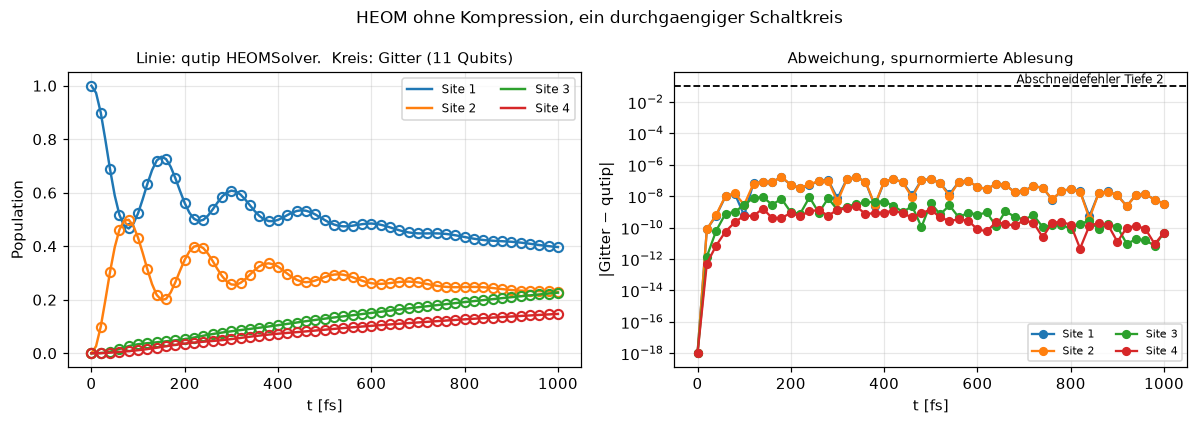

In [12]:
t_fs   = np.arange(N_STEPS + 1) * dt_fs
ref    = qutip_reference(t_fs, rho0=rho0, depth=DEPTH, Nk=NK, **MODEL)
ref3   = qutip_reference(t_fs, rho0=rho0, depth=DEPTH + 1, Nk=NK, **MODEL)
js     = info['t_index']
ok     = np.isfinite(pops_tr[:, 0])

e_tr = np.abs(pops_tr[ok] - ref[js[ok]]).max()
e_p  = np.abs(pops[ok]    - ref[js[ok]]).max()
e_ph = np.abs(ref - ref3).max()
print(f"  Schaltkreis vs qutip HEOMSolver, beide Tiefe {DEPTH}:")
print(f"    spurnormierte Ablesung           : {e_tr:.3e}")
print(f"    Norm aus dem Messprotokoll       : {e_p:.3e}   ({SHOTS} Shots)")
print(f"  zum Vergleich, PHYSIKALISCHER Abschneidefehler Tiefe {DEPTH} vs {DEPTH+1}:")
print(f"    qutip(Tiefe {DEPTH}) vs qutip(Tiefe {DEPTH+1}) : {e_ph:.3e}")
print(f"  Post-Selektion nach {N_STEPS} Schritten : {info['p_success'][-1]:.4f}"
      f"  ({info['accepted'][-1]}/{SHOTS} Shots)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
for j in range(N):
    ax[0].plot(t_fs, ref[:, j], color=cols[j], lw=1.6, label=f'Site {j+1}')
    ax[0].plot(t_fs[js[ok]], pops_tr[ok, j], 'o', ms=6, mfc='none',
               mew=1.4, color=cols[j])
ax[0].set_xlabel('t [fs]'); ax[0].set_ylabel('Population')
ax[0].set_title(f'Linie: qutip HEOMSolver.  Kreis: Gitter ({grid["n_qubits"]} Qubits)')
ax[0].legend(ncol=2)

for j in range(N):
    ax[1].semilogy(t_fs[js[ok]], np.abs(pops_tr[ok, j] - ref[js[ok], j]) + 1e-18,
                   'o-', ms=5, color=cols[j], label=f'Site {j+1}')
ax[1].axhline(e_ph, color='k', ls='--', lw=1.2)
ax[1].text(t_fs[-1], e_ph * 1.4, f'Abschneidefehler Tiefe {DEPTH}', ha='right',
           fontsize=8)
ax[1].set_xlabel('t [fs]'); ax[1].set_ylabel(r'$|$Gitter $-$ qutip$|$')
ax[1].set_title('Abweichung, spurnormierte Ablesung'); ax[1].legend(ncol=2, fontsize=7)

fig.suptitle('HEOM ohne Kompression, ein durchgaengiger Schaltkreis', fontsize=11)
fig.tight_layout(); fig.savefig(f'{PIC}/ohne_kompression.png', dpi=150,
                                bbox_inches='tight')
plt.show()

## 7  Ablesung aus echten Zählraten — Diagonale **und** Off-Diagonale

Bis hierhin hat `run_full` den **Statevector** aus dem Simulator gelesen. Auf echter
Hardware gibt es den nicht; man bekommt Zählraten. `run_full_counts` macht genau das —
und ohne Kompression wird es deutlich billiger als in `gauge_circuit.py`:

$$\operatorname{vec}\rho_S \;=\; \mathrm{scale}[:d^2]\odot\tilde x[:d^2]$$

Die Ablesezeile $r_{jj}$ ist damit ein **einzelner Basisvektor**. Daraus folgt zweierlei:

* **Die Diagonale braucht keine Basisdrehung.** Man misst das Systemregister in der
  Rechenbasis, und *ein* Histogramm liefert alle $d$ Populationen gleichzeitig — im
  komprimierten Fall kostet das $d$ getrennte Schaltkreise.
  $$q_{jj} = P\big(\text{Basiszustand } j+dj \;\big|\; \text{akzeptiert}\big),\qquad \rho_{jj} = \mathrm{scale}_{jj}\,\lambda_t\sqrt{q_{jj}},\qquad \lambda_t = \lVert\tilde x_0\rVert\,s^t\sqrt{p_t}$$
* **Die Off-Diagonale kostet zwei Schaltkreise pro Paar**, mit der ++/RR-Drehung auf
  genau **vier** Koordinaten $(aa, bb, ab, ba)$:
  $$\rho_{++} = \tfrac12(\rho_{aa}+\rho_{bb}) + \mathrm{Re}\,\rho_{ab},\qquad \rho_{RR} = \tfrac12(\rho_{aa}+\rho_{bb}) + \mathrm{Im}\,\rho_{ab}$$
  Beides sind echte Besetzungen, also $\ge0$ nach Cauchy–Schwarz und AM–GM — die Wurzel
  ist eindeutig, eine Phasenreferenz braucht es nicht. Die Drehung ist ein eingebetteter
  $4\times4$-Block, also $O(1)$ klassisch statt einer dichten $1024\times1024$-Matrix.
  Das ist auch für die Skalierungsfrage relevant: eine dichte Drehung wäre ein weiterer
  nicht skalierender Schritt gewesen.

Der absolute Fehler ist $\lVert r\rVert\lambda_t/(2\sqrt{N_{\rm akz}})$ — **unabhängig von
$q$**. Für $\mathrm{Re}$ und $\mathrm{Im}$ kommen die beiden Diagonalbeiträge quadratisch
hinzu.

Jede Auslesezeit braucht einen eigenen Schaltkreis, weil die Messung den Zustand
zerstört. Die Kosten sind deshalb $\big(\sum_t t\big)\times(1+2\,|\text{Paare}|)\times N_{\rm shots}$
Gatteranwendungen. `counts_cost` rechnet das vorher aus.

### Was die Zählraten **nicht** können

Eine Population mit $q_{jj} = (\rho_{jj}/\lambda_t)^2$ braucht $N\gtrsim 1/q_{jj}$ Shots,
um überhaupt **einen einzigen** Treffer zu sehen. Im Testmodell ist bei $t=6$
$q_{33}=3{,}6\cdot10^{-4}$ und $q_{44}=3{,}6\cdot10^{-5}$ — der erste Treffer käme also
erst bei 2 800 bzw. 28 000 Shots. Bei den 128 Shots unten liest man dort exakt **null** ab.

Das ist kein Rechenfehler: der Fehlerbalken $\lambda_t/(2\sqrt{N_{\rm akz}})\approx0{,}044$
deckt die wahren Werte 0,019 und 0,006 mühelos ab. Aber die Null ist uninformativ, und wer
kleine Populationen *auflösen* will, zahlt quadratisch in der Genauigkeit. Die Zelle unten
weist deshalb aus, welche Einträge unter der Nachweisgrenze liegen.

In [ ]:
# --- Parameter des Zaehlraten-Laufs ---------------------------------------
N_CNT, EVERY_CNT, SHOTS_CNT = 8, 2, 128
# N_CNT, EVERY_CNT, SHOTS_CNT = 100, 10, 128
PAIRS = [(0, 1), (1, 2)]      # bestimmt welche offdiagonalelemente geplottet werden

# Erst die Kosten, dann der Lauf.  Der absolute Fehler je Ablesung ist
# lambda_t / (2 sqrt(N_akz)), also ~0.5/sqrt(N) -- daher die Spalte rechts.
cc = counts_cost(grid, N_CNT, SHOTS_CNT, n_pairs=len(PAIRS),
                 save_every=EVERY_CNT)

print(f"\n  Was andere Shot-Zahlen kosten wuerden (gleiche Auslesezeiten, "
      f"{1+2*len(PAIRS)} Kreise je Zeit):")
print(f"  {'Shots':>7s} {'Anwendungen':>13s} {'Laufzeit':>11s} {'~Fehler je Eintrag':>20s}")
for sh in (64, 128, 256, 512, 1024, 4096):
    apps = sum(cc['times']) * cc['circuits_per_time'] * sh
    sek = cc['per_application'] * apps
    fehler = 0.5 / np.sqrt(0.95 * sh)          # lambda_t/(2 sqrt(p*N)), lambda ~ 1
    mark = '   <-- gewaehlt' if sh == SHOTS_CNT else ''
    print(f"  {sh:7d} {apps:13,d} {sek/60:9.1f} min {fehler:20.4f}{mark}")

  Kostenschaetzung Zaehlraten-Ablesung
    Auslesezeiten        : [10, 20, 30, 40, 50]
    Schaltkreise je Zeit : 5 (1 Diagonale + 2 x 2 Paare)
    Shots je Schaltkreis : 128
    Gatteranwendungen    : sum(t) x 5 x 128 = 96,000
    pro Anwendung        : 33.1 ms
    HOCHRECHNUNG         : 53.0 min (3179 s)

  Was andere Shot-Zahlen kosten wuerden (gleiche Auslesezeiten, 5 Kreise je Zeit):
    Shots   Anwendungen    Laufzeit   ~Fehler je Eintrag
       64        48,000      26.5 min               0.0641
      128        96,000      53.0 min               0.0453   <-- gewaehlt
      256       192,000     106.0 min               0.0321
      512       384,000     211.9 min               0.0227
     1024       768,000     423.9 min               0.0160
     4096     3,072,000    1695.5 min               0.0080


  aus data/counts_n8_e2_s128_p2.npz geladen (310 s Rechenzeit gespart)
12.5%. Run time:   0.00s. Est. time left: 00:00:00:00
25.0%. Run time:   0.00s. Est. time left: 00:00:00:00
37.5%. Run time:   0.00s. Est. time left: 00:00:00:00
50.0%. Run time:   0.00s. Est. time left: 00:00:00:00
62.5%. Run time:   0.01s. Est. time left: 00:00:00:00
75.0%. Run time:   0.01s. Est. time left: 00:00:00:00
87.5%. Run time:   0.01s. Est. time left: 00:00:00:00
100.0%. Run time:   0.01s. Est. time left: 00:00:00:00
Total run time:   0.01s


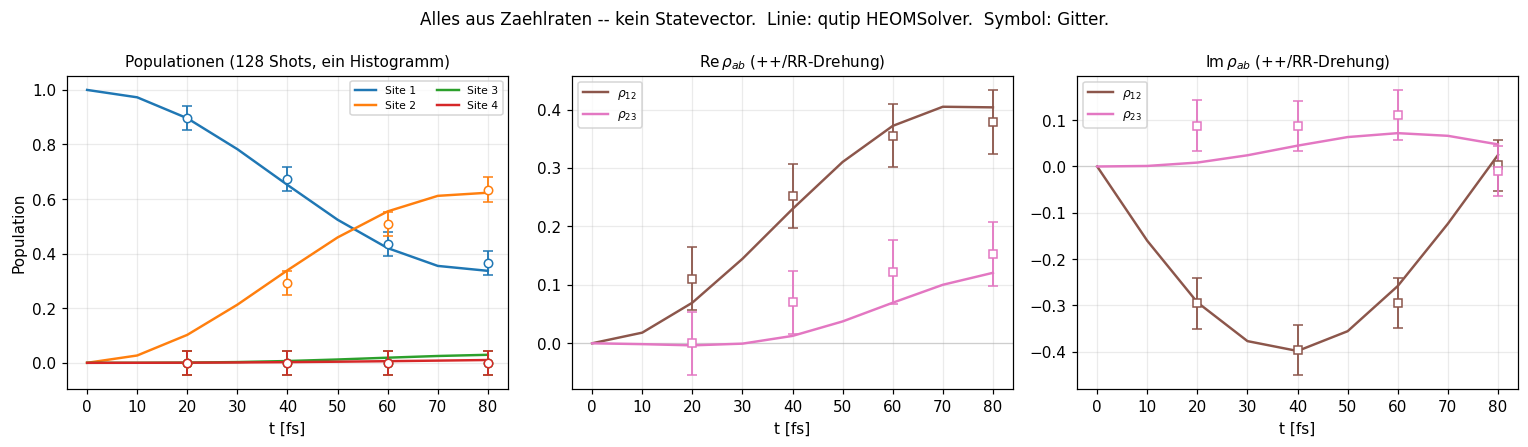


  t =   20 fs | p_succ 1.000 | Spur 0.8983 | max|dPop| 0.1025 = 2.3 sigma
           rho_12: |dRe| 0.0412 (0.8 sigma)   |dIm| 0.0023 (0.0 sigma)
           rho_23: |dRe| 0.0036 (0.1 sigma)   |dIm| 0.0800 (1.5 sigma)
  t =   40 fs | p_succ 0.992 | Spur 0.9689 | max|dPop| 0.0452 = 1.0 sigma
           rho_12: |dRe| 0.0219 (0.4 sigma)   |dIm| 0.0025 (0.0 sigma)
           rho_23: |dRe| 0.0575 (1.1 sigma)   |dIm| 0.0425 (0.8 sigma)
  t =   60 fs | p_succ 0.984 | Spur 0.9446 | max|dPop| 0.0451 = 1.0 sigma
           rho_12: |dRe| 0.0166 (0.3 sigma)   |dIm| 0.0367 (0.7 sigma)
           rho_23: |dRe| 0.0522 (1.0 sigma)   |dIm| 0.0390 (0.7 sigma)
  t =   80 fs | p_succ 0.984 | Spur 1.0011 | max|dPop| 0.0294 = 0.7 sigma
           rho_12: |dRe| 0.0246 (0.5 sigma)   |dIm| 0.0226 (0.4 sigma)
           rho_23: |dRe| 0.0323 (0.6 sigma)   |dIm| 0.0572 (1.1 sigma)

  Nachweisgrenze der Zaehlraten-Ablesung:
    t=  20 fs  rho_33 = 0.0008: erster Treffer erst bei ~1,434,453 Shots -> hier als 0 abgel

In [23]:
# Der Lauf dauert Minuten; das Ergebnis wird deshalb zwischengespeichert, damit
# man die Abbildung ohne Neurechnung anpassen kann.  Zum Neurechnen die Datei
# loeschen oder CACHE_CNT = None setzen.
os.makedirs('data', exist_ok=True)
CACHE_CNT = (f'data/counts_n{N_CNT}_e{EVERY_CNT}_s{SHOTS_CNT}'
             f'_p{len(PAIRS)}.npz')

if CACHE_CNT and os.path.exists(CACHE_CNT):
    _z = np.load(CACHE_CNT, allow_pickle=True)
    rho_c, err_re, err_im = _z['rho'], _z['err_re'], _z['err_im']
    info_c = _z['info'].item()
    print(f"  aus {CACHE_CNT} geladen ({info_c['wall_seconds']:.0f} s "
          f"Rechenzeit gespart)")
else:
    rho_c, err_re, info_c = run_full_counts(grid, N_CNT, PAIRS,
                                            shots=SHOTS_CNT,
                                            save_every=EVERY_CNT)
    err_im = info_c['rho_err_im']
    if CACHE_CNT:
        np.savez(CACHE_CNT, rho=rho_c, err_re=err_re, err_im=err_im,
                 info=np.array(info_c, dtype=object))
jc = info_c['t_index']
okc = np.isfinite(np.real(rho_c[:, 0, 0]))

t_ex = np.arange(N_CNT + 1) * dt_fs
rho_ex = qutip_reference_rho(t_ex, rho0=rho0, depth=DEPTH, Nk=NK, **MODEL)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.1))

# (a) Populationen -- alle vier aus EINEM Histogramm
for j in range(N):
    ax[0].plot(t_ex, np.real(rho_ex[:, j, j]), color=cols[j], lw=1.6,
               label=f'Site {j+1}')
    ax[0].errorbar(jc[okc] * dt_fs, np.real(rho_c[okc, j, j]),
                   yerr=err_re[okc, j, j], fmt='o', ms=5.5, capsize=3.5,
                   lw=1.2, color=cols[j], mfc='white')
ax[0].set_title(f'Populationen ({SHOTS_CNT} Shots, ein Histogramm)')
ax[0].set_ylabel('Population'); ax[0].legend(ncol=2, fontsize=7)

# (b), (c) Real- und Imaginaerteil der gewaehlten Paare
for m, (part, lab, err) in enumerate(((np.real, r'\mathrm{Re}', err_re),
                                      (np.imag, r'\mathrm{Im}', err_im))):
    A = ax[m + 1]
    A.axhline(0, color='0.85', lw=0.8, zorder=0)
    for i, (a, b) in enumerate(PAIRS):
        A.plot(t_ex, part(rho_ex[:, a, b]), color=f'C{i+5}', lw=1.6,
               label=rf'$\rho_{{{a+1}{b+1}}}$')
        A.errorbar(jc[okc] * dt_fs, part(rho_c[okc, a, b]), yerr=err[okc, a, b],
                   fmt='s', ms=5.5, capsize=3.5, lw=1.2, color=f'C{i+5}',
                   mfc='white')
    A.set_title(rf'${lab}\,\rho_{{ab}}$ (++/RR-Drehung)')
    A.legend(fontsize=8)

for A in ax:
    A.set_xlabel('t [fs]'); A.grid(alpha=.25)
fig.suptitle('Alles aus Zaehlraten -- kein Statevector.  Linie: qutip HEOMSolver.  '
             'Symbol: Gitter.', fontsize=11)
fig.tight_layout()
fig.savefig(f'{PIC}/zaehlraten.png', dpi=150, bbox_inches='tight')
plt.show()

print()
for k in np.where(okc)[0]:
    t = jc[k]
    dpop = np.abs(np.real(np.diag(rho_c[k])) - np.real(np.diag(rho_ex[t]))).max()
    z = dpop / err_re[k, 0, 0]
    print(f"  t = {t*dt_fs:4.0f} fs | p_succ {info_c['p_success'][k]:.3f} | "
          f"Spur {np.real(np.trace(rho_c[k])):.4f} | "
          f"max|dPop| {dpop:.4f} = {z:.1f} sigma")
    for (a, b) in PAIRS:
        dr = abs(np.real(rho_c[k, a, b] - rho_ex[t, a, b]))
        di = abs(np.imag(rho_c[k, a, b] - rho_ex[t, a, b]))
        print(f"           rho_{a+1}{b+1}: |dRe| {dr:.4f} "
              f"({dr/err_re[k,a,b]:.1f} sigma)   |dIm| {di:.4f} "
              f"({di/err_im[k,a,b]:.1f} sigma)")
# Welche Eintraege liegen unter der Nachweisgrenze?  q = (rho/lambda)^2, und der
# erste Treffer kommt im Mittel bei N ~ 1/q.
print("\n  Nachweisgrenze der Zaehlraten-Ablesung:")
for k in np.where(okc)[0]:
    t = jc[k]
    lam_k = np.sqrt(np.sum(np.abs(np.real(np.diag(rho_ex[t]))) ** 2)) or 1.0
    for j in range(N):
        p_true = float(np.real(rho_ex[t, j, j]))
        q_j = (p_true / max(info_c['p_success'][k] ** 0.5, 1e-12)) ** 2
        need = int(np.ceil(1.0 / q_j)) if q_j > 0 else 0
        if need > SHOTS_CNT:
            print(f"    t={t*dt_fs:4.0f} fs  rho_{j+1}{j+1} = {p_true:.4f}: "
                  f"erster Treffer erst bei ~{need:,} Shots "
                  f"-> hier als 0 abgelesen")

print(f"\n  {info_c['n_circuits']} Schaltkreise, {info_c['applications']:,} "
      f"Gatteranwendungen, {info_c['wall_seconds']:.0f} s "
      f"({info_c['wall_seconds']/info_c['applications']*1e3:.1f} ms je Anwendung)")

## 8  Der Schaltkreis

Drei Wiederholungen der einen Einheit. Der volle Lauf ist dasselbe Bild, nur
$n$-mal — es kommt kein neuer Gattertyp hinzu, egal wie lang die Propagation wird.

  11 Qubits, ein Gattertyp U (2048 x 2048), Tiefe 9 fuer 3 Schritte


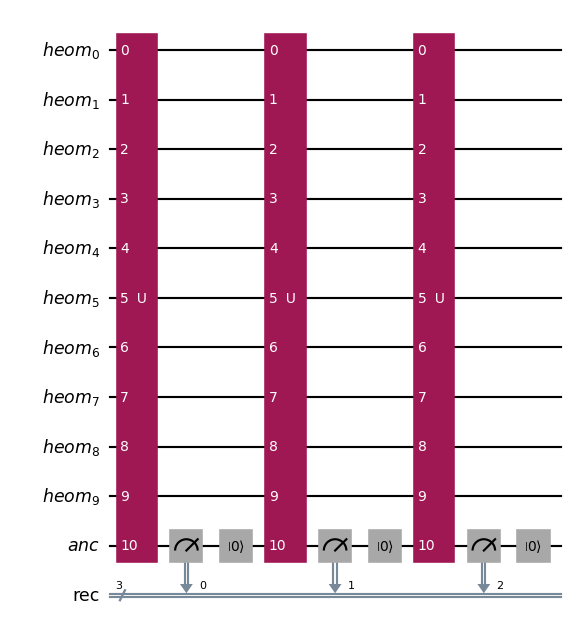

In [20]:
qc3 = build_circuit_full(grid, 3, save_states=False)
fig = qc3.draw('mpl', fold=-1, scale=0.7)
fig.savefig(f'{PIC}/schaltkreis.png', dpi=150, bbox_inches='tight')
print(f"  {grid['n_qubits']} Qubits, ein Gattertyp U ({2*grid['np_']} x "
      f"{2*grid['np_']}), Tiefe {qc3.depth()} fuer 3 Schritte")
fig

---

### Was hier bewiesen ist — und was nicht

**Bewiesen:** Die Dynamik läuft auf einem durchgängigen Schaltkreis, ohne dass ein
einziger Zeitschritt klassisch propagiert wird, und stimmt mit dem exakten qutip-Solver
überein. Der klassische Aufwand ist unabhängig von der Zahl der Zeitschritte.

**Nicht bewiesen:** dass das für ein großes System funktioniert. Der klassische Aufwand
ist zwar unabhängig von der Zahl der *Zeitschritte*, aber nicht von der Hilbertraum-
*Dimension*: $\exp(A\Delta t)$ und die Dilatation sind dichte $O(n^3)$-Operationen.
Was das für die $10^{30}\times10^{30}$-Frage bedeutet, steht in
[`kritik.ipynb`](kritik.ipynb).